In [1]:
# !pip install numpy scikit-learn gurobipy

In [2]:
import numpy as np
import gurobipy as gp
from gurobipy import GRB
from sklearn.linear_model import Lasso,LassoCV
from sklearn.metrics import mean_squared_error,confusion_matrix
import time
import random
from MIP import hard_thresholding, solve_mip
import matplotlib.pyplot as plt
import kagglehub
import pandas as pd


/Users/polamoscicka/anaconda3/envs/mio_env/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
# path = kagglehub.dataset_download("mathchi/diabetes-data-set")
# data=pd.read_csv(path+"/diabetes.csv")
# data

# Data generation

In [4]:
np.random.seed(42)

n, p = 300, 40
k_true = 10

X = np.random.randn(n, p)

true_beta = np.zeros(p)
true_beta[:k_true] = np.random.randint(1, 11, k_true)

y = X @ true_beta #+ 0.5 * np.random.randn(n)

# Lasso & MIP

In [5]:
lasso = Lasso(alpha=0.1)

start_lasso = time.time()
lasso.fit(X, y)
beta_lasso = lasso.coef_
end_lasso = time.time()


mse_lasso = mean_squared_error(y, X @ beta_lasso)


In [6]:
k = k_true

beta_init = hard_thresholding(X, y, k=5, steps=200, lr=0.01)

start_mip = time.time()
beta_mip, z_mip = solve_mip(X, y, k, beta_init=beta_init)
end_mip = time.time()

mse_mip = mean_squared_error(y, X @ beta_mip)

Restricted license - for non-production use only - expires 2027-11-29


# Generate synthetic data 

In [7]:
#page 26 example 1 (b0 changed)
def generate_data(n, p=20, k_true=10, rho=0.5, snr=3, seed=10):
    np.random.seed(seed)
    
    Sigma = np.zeros((p, p))
    for i in range(p):
        for j in range(p):
            Sigma[i, j] = rho ** abs(i - j)
            

    X = np.random.multivariate_normal(np.zeros(p), Sigma, n)

    X = X - np.mean(X, axis=0)
    norm = np.linalg.norm(X, axis=0)
    norm[norm == 0] = 1
    X = X / norm
    
    beta0 = np.zeros(p)
    non_zero= np.random.choice(p, k_true, replace=False)
    beta0[non_zero] = np.random.uniform(1, 10, k_true) * np.random.choice([-1, 1], k_true)
    
    y0= X @ beta0

    
    var_f = np.var(y0)
    var_noise = var_f / snr
    
    y = y0 + np.random.normal(0, np.sqrt(var_noise), n)
    #y=y0
    
    return X, y, beta0

In [8]:
def evaluate(beta0, beta_pred, a=1e-3):

    true_nz = np.abs(beta0) > a
    pred_nz = np.abs(beta_pred) > a
    s = np.sum(pred_nz)
    
    TN, FP, FN, TP = confusion_matrix(true_nz, pred_nz).ravel()
    
    if TP+FN==0:
        TPR=0
    else:  TPR = TP / (TP + FN)

    if FP + TN == 0:
        FPR = 0
    else: FPR = FP / (FP + TN)
    
    
    return TPR, FPR, s

# Visual

In [9]:
p = 20
k_values = [ 6, 10, 13] 
n_values = [100, 200,300,500,750,1000,1500,2000,2500]
seeds = [10,20,30,40,50]

In [10]:
results = {
    'lasso': {'tpr': {n: [] for n in n_values}, 'fpr': {n: [] for n in n_values}, 's': {n: [] for n in n_values}},
    'mip':   {'tpr': {n: [] for n in n_values}, 'fpr': {n: [] for n in n_values}, 's': {n: [] for n in n_values}}
}
beta_mse_lasso = {k: {n: [] for n in n_values} for k in k_values}
beta_mse_mip = {k: {n: [] for n in n_values} for k in k_values}

time_lasso = {k: {n: [] for n in n_values} for k in k_values}
time_mip = {k: {n: [] for n in n_values} for k in k_values}

for k0 in k_values:
    print(f"start k0={k0}")
    for n in n_values:
        for seed in seeds:

            X, y, true_beta = generate_data(n=n, p=p, k_true=k0, rho=0.5, snr=3, seed=seed)
            
            start_lasso = time.time()
            #lasso = Lasso(alpha=0.001)
            lasso=LassoCV(cv=5, max_iter=10000)
            lasso.fit(X, y)
            end_lasso = time.time()
        
            beta_lasso = lasso.coef_
            err_lasso = mean_squared_error(true_beta, beta_lasso)
            
            time_lasso[k0][n].append(end_lasso - start_lasso)
            beta_mse_lasso[k0][n].append(err_lasso)

            tpr_l, fpr_l, s_l = evaluate(true_beta, lasso.coef_)
            results['lasso']['tpr'][n].append(tpr_l)
            results['lasso']['fpr'][n].append(fpr_l)
            results['lasso']['s'][n].append(s_l)
            

            start_mip = time.time()
            beta_init = hard_thresholding(X, y, k=k0, steps=200, lr=0.01)
            beta_mip, z_mip = solve_mip(X, y, k=k0, beta_init=beta_init, time_limit=100)
            end_mip = time.time()
            
            err_mip = mean_squared_error(true_beta, beta_mip)     
            time_mip[k0][n].append(end_mip - start_mip)
            beta_mse_mip[k0][n].append(err_mip)

            tpr_m, fpr_m, s_m = evaluate(true_beta, beta_mip)
            results['mip']['tpr'][n].append(tpr_m)
            results['mip']['fpr'][n].append(fpr_m)
            results['mip']['s'][n].append(s_m)
                
        print(f"  Zakończono n={n}")


avg_mse_lasso = {k: [np.mean(beta_mse_lasso[k][n]) for n in n_values] for k in k_values}
avg_mse_mip = {k: [np.mean(beta_mse_mip[k][n]) for n in n_values] for k in k_values}

avg_time_lasso = {k: [np.mean(time_lasso[k][n]) for n in n_values] for k in k_values}
avg_time_mip = {k: [np.mean(time_mip[k][n]) for n in n_values] for k in k_values}



start k0=6
  Zakończono n=100
  Zakończono n=200
  Zakończono n=300
  Zakończono n=500
  Zakończono n=750
  Zakończono n=1000
  Zakończono n=1500
  Zakończono n=2000
  Zakończono n=2500
start k0=10
  Zakończono n=100
  Zakończono n=200
  Zakończono n=300
  Zakończono n=500
  Zakończono n=750
  Zakończono n=1000
  Zakończono n=1500
  Zakończono n=2000
  Zakończono n=2500
start k0=13
  Zakończono n=100
  Zakończono n=200
  Zakończono n=300
  Zakończono n=500
  Zakończono n=750
  Zakończono n=1000
  Zakończono n=1500
  Zakończono n=2000
  Zakończono n=2500


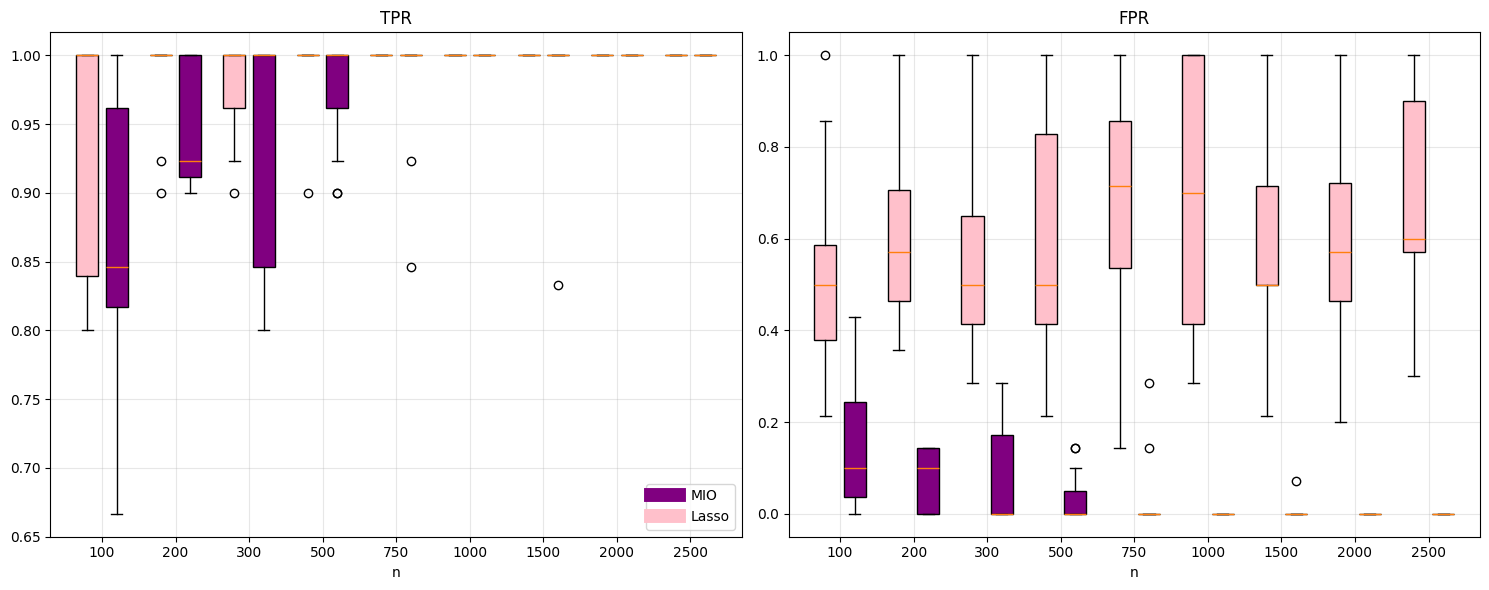

In [11]:


metrics = ['tpr', 'fpr', 's']
titles = ['TPR', 'FPR']

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

for ax, metric, title in zip(axes, metrics, titles):

    data_lasso = [results['lasso'][metric][n] for n in n_values]
    data_mip   = [results['mip'][metric][n] for n in n_values]

    pos_lasso = [i - 0.2 for i in range(len(n_values))]
    pos_mip   = [i + 0.2 for i in range(len(n_values))]

    bp1 = ax.boxplot(
        data_lasso,
        positions=pos_lasso,
        widths=0.3,
        patch_artist=True
    )

    bp2 = ax.boxplot(
        data_mip,
        positions=pos_mip,
        widths=0.3,
        patch_artist=True

    )

    for box in bp1['boxes']:
        box.set_facecolor('pink')

    for box in bp2['boxes']:
        box.set_facecolor('purple')

    ax.set_title(title)
    ax.set_xlabel("n")
    ax.set_xticks(range(len(n_values)))
    ax.set_xticklabels(n_values)
    ax.grid(True, alpha=0.3)

axes[0].plot([], [], color='purple', linewidth=10, label='MIO')
axes[0].plot([], [], color='pink', linewidth=10, label='Lasso')

axes[0].legend()

plt.tight_layout()
plt.show()

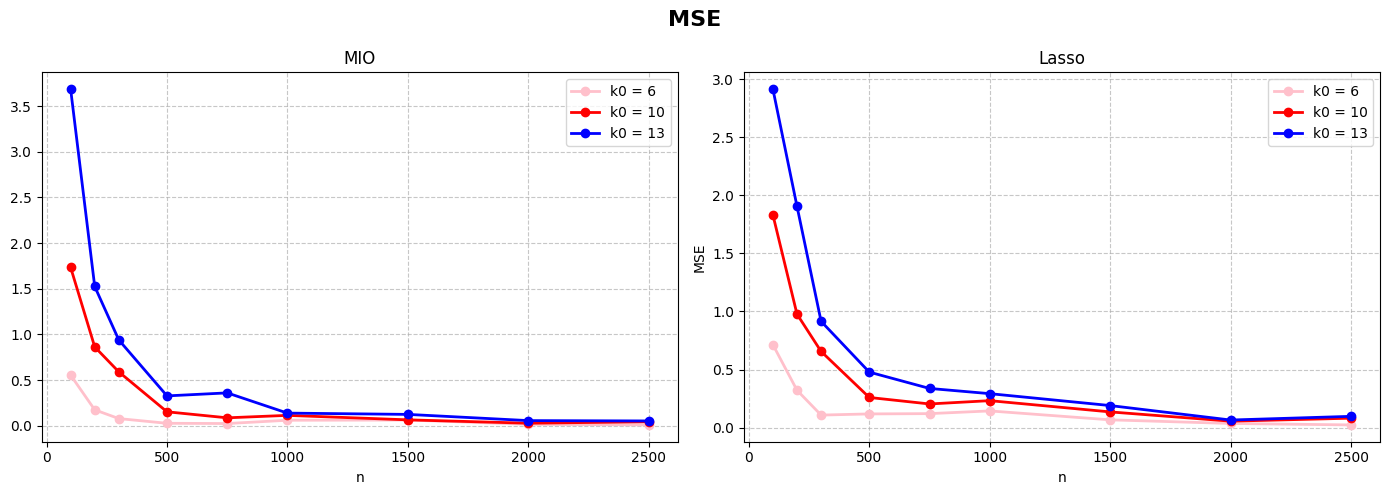

In [12]:

colors = ['pink', 'red', 'blue'] 
markers = ['o', 's', '^']

fig_mse, (ax_mip_mse,ax_lasso_mse) = plt.subplots(nrows=1, ncols=2, figsize=(14, 5))
fig_mse.suptitle('MSE', fontsize=16, fontweight='bold')

for i, k0 in enumerate(k_values):
    ax_mip_mse.plot(n_values, avg_mse_mip[k0], 
                    color=colors[i], marker='o', linewidth=2, 
                    label=f'k0 = {k0}')
    ax_lasso_mse.plot(n_values, avg_mse_lasso[k0], 
                      color=colors[i], marker='o', linewidth=2, 
                      label=f'k0 = {k0}')
 
    

ax_mip_mse.set_title('MIO')
ax_mip_mse.set_xlabel('n')
ax_mip_mse.legend()
ax_mip_mse.grid(True, linestyle='--', alpha=0.7)

ax_lasso_mse.set_title('Lasso')
ax_lasso_mse.set_xlabel('n')
ax_lasso_mse.set_ylabel('MSE')
ax_lasso_mse.legend()
ax_lasso_mse.grid(True, linestyle='--', alpha=0.7)


plt.tight_layout()
plt.show()



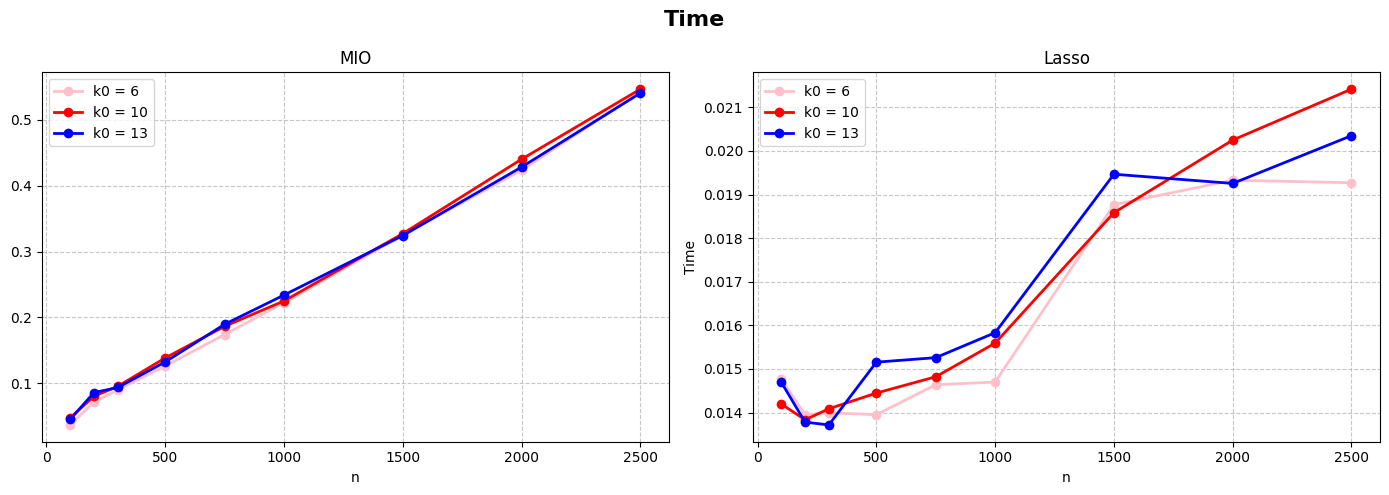

In [13]:

colors = ['pink', 'red', 'blue'] 

fig_mse, ( ax_mip_mse,ax_lasso_mse) = plt.subplots(nrows=1, ncols=2, figsize=(14, 5))
fig_mse.suptitle('Time', fontsize=16, fontweight='bold')

for i, k0 in enumerate(k_values):
    ax_mip_mse.plot(n_values, avg_time_mip[k0], 
                    color=colors[i], marker='o', linewidth=2, 
                    label=f'k0 = {k0}')
    ax_lasso_mse.plot(n_values, avg_time_lasso[k0], 
                      color=colors[i], marker='o', linewidth=2, 
                      label=f'k0 = {k0}')
 
    

ax_mip_mse.set_title('MIO')
ax_mip_mse.set_xlabel('n')
ax_mip_mse.legend()
ax_mip_mse.grid(True, linestyle='--', alpha=0.7)

ax_lasso_mse.set_title('Lasso')
ax_lasso_mse.set_xlabel('n')
ax_lasso_mse.set_ylabel('Time')
ax_lasso_mse.legend()
ax_lasso_mse.grid(True, linestyle='--', alpha=0.7)


plt.tight_layout()
plt.show()



In [14]:

# beta_mse_lasso = {n: [] for n in n_values}
# beta_mse_mip = {n: [] for n in n_values}
# time_lasso = {n: [] for n in n_values}
# time_mip = {n: [] for n in n_values}


# for n in n_values:
#     for seed in seeds:
#         X, y, true_beta = generate_data(n=n, p=p, k_true=k_true, rho=0.5, snr=3.0, seed=seed)
        
#         #Lasso

#         start_lasso = time.time()
#         lasso = Lasso(alpha=0.1)
#         lasso.fit(X, y)
#         end_lasso = time.time()
    
#         beta_lasso = lasso.coef_
#         err_lasso = mean_squared_error(true_beta, beta_lasso)
        
#         time_lasso[n].append(end_lasso - start_lasso)
#         beta_mse_lasso[n].append(err_lasso)
        
#         #MIP
#         start_mip = time.time()
#         beta_init = hard_thresholding(X, y, k=6, steps=200, lr=0.01)
#         beta_mip, z_mip = solve_mip(X, y, k=6, beta_init=beta_init, time_limit=100)
#         end_mip = time.time()
        

#         err_mip = mean_squared_error(true_beta, beta_mip)     
#         time_mip[n].append(end_mip - start_mip)
#         beta_mse_mip[n].append(err_mip)
        
#     print(f"Done n={n}")


# avg_mse_lasso = [np.mean(beta_mse_lasso[n]) for n in n_values]
# avg_mse_mip = [np.mean(beta_mse_mip[n]) for n in n_values]

# avg_time_lasso = [np.mean(time_lasso[n]) for n in n_values]
# avg_time_mip = [np.mean(time_mip[n]) for n in n_values]




In [15]:
# fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))


# ax1.plot(n_values, avg_mse_lasso, marker='o', label='Lasso', color='pink', linewidth=2)
# ax1.plot(n_values, avg_mse_mip, marker='o', label='MIO', color='blue', linewidth=2)
# ax1.set_title('MSE vs n')
# ax1.set_xlabel('n')
# ax1.set_ylabel('MSE($\\beta_{true}$, $\\hat{\\beta}$)')
# ax1.legend()
# ax1.grid(True, linestyle='--', alpha=0.7)


# ax2.plot(n_values, avg_time_lasso, marker='o', label='Lasso', color='pink', linewidth=2)
# ax2.plot(n_values, avg_time_mip, marker='o', label='MIO', color='blue', linewidth=2)
# ax2.set_title('Time vs n')
# ax2.set_xlabel('n')
# ax2.set_ylabel('Averaged time (s)')
# ax2.legend()
# ax2.grid(True, linestyle='--', alpha=0.7)


# plt.tight_layout()

# Results

In [16]:
print("LASSO")
print("beta:", beta_lasso)
print("MSE:", mse_lasso)
print("time:", round(end_lasso - start_lasso, 2), "s")

print("\n")

print("MIP")
print("beta:", beta_mip)
print("MSE:", mse_mip)
print("time:", round(end_mip - start_mip, 2), "s")

LASSO
beta: [ 0.         -4.96321645  7.61607512  2.38477892 -0.         -8.58943506
  0.         -4.68830362  3.19207406  1.3523539   0.29321892  8.76720861
 -2.9304594  -6.62296499 -0.12611747 -2.00948169  0.25689801  0.46432848
  4.2701096  -7.55451101]
MSE: 0.11153070731270166
time: 0.02 s


MIP
beta: [ 0.         -5.04130414  7.68608854  2.42852837  0.         -8.64282847
  0.         -4.75983177  3.25392856  1.48382145  0.          8.94063357
 -2.9912356  -6.68414314  0.         -1.89615014  0.          0.
  4.62093539 -7.64159009]
MSE: 0.0
time: 0.55 s
